# PV generation comparisons - Geodata PV vs PVLib

## Load Modules and Import Data

In [47]:
import geodata
import numpy as np
import pandas as pd
import time
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns


import pvlib
from pvlib.pvsystem import PVSystem, FixedMount
from pvlib.location import Location
from pvlib.modelchain import ModelChain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
from pvlib import irradiance
from pvlib.solarposition import get_solarposition

from timezonefinder import TimezoneFinder

In [4]:
DS = geodata.Dataset(
    module="era5",
    weather_data_config="wind_solar_hourly",
    years=slice(2024, 2024),
    months=slice(1, 12),
    bounds=[50, -3, 45, 3], ## double check this at some point
)

DS.get_data()

cutout = geodata.Cutout(
    name="era5-europe-test-2024a",
    module="era5",
    weather_data_config="wind_solar_hourly",
    ys=slice(1, 2),
    xs=slice(47, 48),
    years=slice(2024, 2024),
    months=slice(1, 12)
)
cutout.prepare()

2025-03-17 22:56:41,070 - geodata.dataset - INFO - Directory /Users/williamhonaker/Desktop/davidson/era5 found, checking for completeness.
2025-03-17 22:56:41,071 - geodata.dataset - INFO - Directory complete.
2025-03-17 22:56:41,072 - geodata.datasets.era5 - INFO - All ERA5 files for this dataset have been downloaded.
2025-03-17 22:56:41,112 - geodata.cutout - INFO - All cutout (era5-europe-test-2024a, /Users/williamhonaker/Desktop/davidson/cutouts) files available.
2025-03-17 22:56:41,119 - geodata.cutout - INFO - Cutout subset prepared: <Cutout era5-europe-test-2024a x=47.00-48.00 y=2.00-1.00 time=2024/1-2024/12 prepared>
2025-03-17 22:56:41,120 - geodata.preparation - INFO - The cutout is already prepared. If you want to recalculate it, supply an `overwrite=True` argument.


True

## Model Parameters for comparison

In [5]:
lat = 1
lon = 48
slope = 35
azimuth = 180
n_mods = 50
n_strings = 1
tf = TimezoneFinder()
tz_str = tf.timezone_at(lat=lat, lng=lon)
cec_modules = pvlib.pvsystem.retrieve_sam('CECMod') 
module = cec_modules['Kaneka_U_SA105']
inv =  pvlib.pvsystem.retrieve_sam(name="CECInverter")['Fronius_USA__CL_33_3_Delta__208V_']

# Geodata PV generation

Generates a PV series for the indicated cutout in approximately 0.65 seconds.
Cutout is at hourly level for all of 2024, across a 1x1 set of coordinates at 0.25 degree granularity.

In [6]:
start_time = time.time()
print(f"Function start time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

ds_pv = cutout.pv(panel="KANEKA", orientation={'slope': slope,'azimuth': azimuth})

end_time = time.time()
print(f"Function end time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
print(f"Total execution time: {end_time - start_time:.4f} seconds")


Function start time: 2025-03-17 22:56:44
Function end time: 2025-03-17 22:56:45
Total execution time: 0.6003 seconds


In [7]:
df_pv = ds_pv.to_dataframe(name="pv")
print(df_pv)

                               number  lat expver    lon   pv
y   time                x                                    
2.0 2024-01-01 00:00:00 47.00       0  2.0   0001  47.00  0.0
                        47.25       0  2.0   0001  47.25  0.0
                        47.50       0  2.0   0001  47.50  0.0
                        47.75       0  2.0   0001  47.75  0.0
                        48.00       0  2.0   0001  48.00  0.0
...                               ...  ...    ...    ...  ...
1.0 2024-12-31 23:00:00 47.00       0  1.0   0001  47.00  0.0
                        47.25       0  1.0   0001  47.25  0.0
                        47.50       0  1.0   0001  47.50  0.0
                        47.75       0  1.0   0001  47.75  0.0
                        48.00       0  1.0   0001  48.00  0.0

[219600 rows x 5 columns]


In [8]:
df_pv.to_csv("geodata_pv_model_data_031725.csv")

# Geodata PVLib Generation

Generates a PV series for the indicated cutout in approximately 20 seconds.
Cutout is at hourly level for all of 2024, across a 1x1 set of coordinates at 0.25 degree granularity.

In [37]:
start_time = time.time()
print(f"Function start time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")


system = geodata.pvlib.pv_system(
    arrays = None,
    surface_tilt=slope,
    surface_azimuth=azimuth,
    racking_model = 'open_rack',
    module_parameters=module,
    modules_per_string = n_mods,
    module_type = 'glass_polymer',
    module = 'Kaneka_U_SA105',
    strings_per_inverter = n_strings, 
    inverter_parameters=inv
)

model_config = geodata.pvlib.ModelChainConfig(
    clearsky_model= 'haurwitz',
    transposition_model='perez', 
    solar_position_method= 'nrel_numpy',
    airmass_model= 'kastenyoung1989',
    dc_model='cec',
    ac_model='sandia', 
    aoi_model="physical",
    spectral_model='first_solar',
    dc_ohmic_model='no_loss'
)

model = geodata.pvlib.pvlib_model(
    cutout,
    system,
    model_config
)
model


end_time = time.time()
print(f"Function end time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
print(f"Total execution time: {end_time - start_time:.4f} seconds")
df_pvlib = model.to_dataframe()
print(df_pvlib)

2025-03-17 23:29:53,882 - geodata.convert - INFO - Getting variable: influx_diffuse
2025-03-17 23:29:54,037 - geodata.convert - INFO - Getting variable: influx_direct


Function start time: 2025-03-17 23:29:53


2025-03-17 23:29:54,178 - geodata.convert - INFO - Getting variable: dewpoint_temperature
2025-03-17 23:29:54,316 - geodata.convert - INFO - Getting variable: temperature
2025-03-17 23:29:54,451 - geodata.convert - INFO - Getting variable: wnd100m


Function end time: 2025-03-17 23:30:13
Total execution time: 19.4712 seconds
                       y     x        dhi        dni        ghi   temp_air  \
time                                                                         
2024-01-01 00:00:00  2.0  47.0   0.000000   0.000000   0.000000  27.154205   
2024-01-01 01:00:00  2.0  47.0   0.000000   0.000000   0.000000  27.158722   
2024-01-01 02:00:00  2.0  47.0   0.000000   0.000000   0.000000  27.204132   
2024-01-01 03:00:00  2.0  47.0   0.035556   0.000000   0.035556  27.247955   
2024-01-01 04:00:00  2.0  47.0  29.315556  46.844444  69.582030  27.366608   
...                  ...   ...        ...        ...        ...        ...   
2024-12-31 19:00:00  1.0  48.0   0.000000   0.000000   0.000000  26.389862   
2024-12-31 20:00:00  1.0  48.0   0.000000   0.000000   0.000000  26.318146   
2024-12-31 21:00:00  1.0  48.0   0.000000   0.000000   0.000000  26.263092   
2024-12-31 22:00:00  1.0  48.0   0.000000   0.000000   0.000000  

In [ ]:
df_pvlib.to_csv("geodata_pvlib_model_data_031725.csv")

# Example Comparisons

## Descriptive Statistics Comparison

Definitely a difference in the units to account for.

Perhaps this line has a clue? `plt.plot(mc.results.ac/(module.PTC * n_mods), label = 'pvlib python')`

94.5

In [38]:
# Load the two datasets
#df_pv = pd.read_csv("pv_data.csv")  
#df_pvlib = pd.read_csv("pvlib_data.csv")  
df_pvlib['ac_adj'] = df_pvlib['ac'] / (module.PTC*n_mods)
df_merged = pd.merge(df_pv, df_pvlib, on=["time", "lat", "lon"])[['lon', 'lat', 'pv', 'ac_adj']]
stats = df_merged[['pv', 'ac_adj']].describe()
stats

,pv,ac_adj
count,219600.000000,219600.000000
mean,0.181933,0.207212
std,0.243731,0.282269
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.377399,0.406529
max,0.843853,0.983403


In [39]:
stats.loc["range"] = stats.loc["max"] - stats.loc["min"]  # Range
stats.loc["iqr"] = df_merged[['pv', 'ac_adj']].quantile(0.75) - df_merged[['pv', 'ac_adj']].quantile(0.25)  # IQR
stats.loc["skew"] = df_merged[['pv', 'ac_adj']].skew()  # Skewness
stats.loc["kurtosis"] = df_merged[['pv', 'ac_adj']].kurtosis()  # Kurtosis
stats.loc["correlation"] = df_merged[['pv', 'ac_adj']].corr().iloc[0, 1]  # Correlation coefficient
print(stats)

                        pv         ac_adj
count        219600.000000  219600.000000
mean              0.181933       0.207212
std               0.243731       0.282269
min               0.000000       0.000000
25%               0.000000       0.000000
50%               0.000000       0.000000
75%               0.377399       0.406529
max               0.843853       0.983403
range             0.843853       0.983403
iqr               0.377399       0.406529
skew              0.982689       1.085397
kurtosis         -0.490179      -0.232213
correlation       0.990972       0.990972


## Time series

### Daily trend

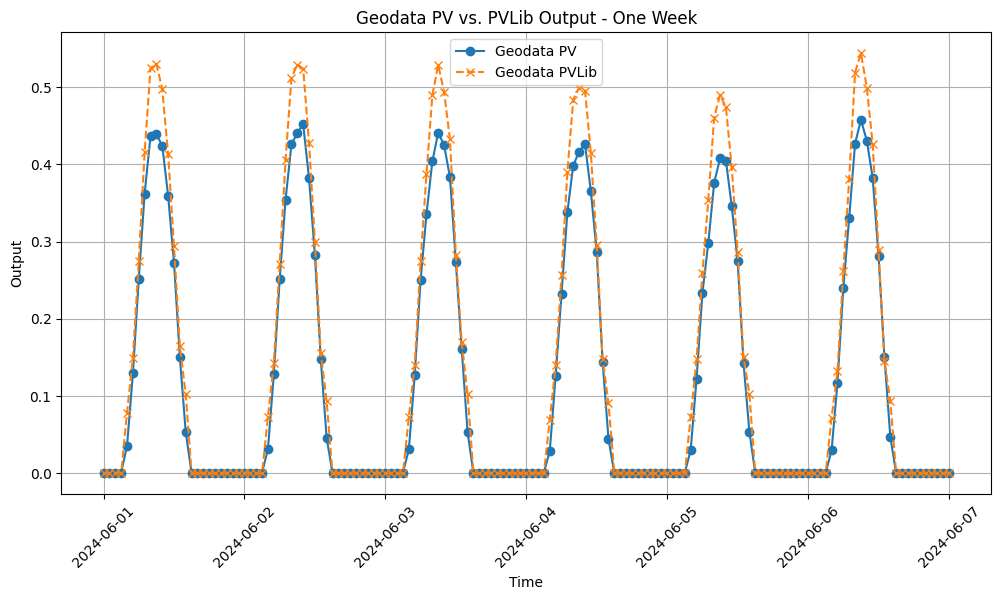

In [44]:
start_date = "2024-06-01"
end_date = "2024-06-07"
df_week = df_merged[(df_merged.index >= start_date) & (df_merged.index <= end_date)].reset_index()
df_week_avg = df_week.groupby("time")[["pv", "ac_adj"]].mean()

plt.figure(figsize=(12, 6))
plt.plot(df_week_avg.index, df_week_avg["pv"], label="Geodata PV", linestyle="-", marker="o")
plt.plot(df_week_avg.index, df_week_avg["ac_adj"], label="Geodata PVLib", linestyle="--", marker="x")
plt.xlabel("Time")
plt.ylabel("Output")
plt.title("Geodata PV vs. PVLib Output - Daily Trend over One Week")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Monthly trend

In [43]:
df_monthly = df_merged.reset_index()
df_monthly["month"] = df_merged.reset_index()["time"].dt.to_period("M")
df_monthly = df_monthly.groupby("month")[["pv", "ac_adj"]].mean()
df_monthly.head()

,pv,ac_adj
month,,
2024-01,0.222943,0.251517
2024-02,0.216580,0.247582
2024-03,0.199704,0.228062
2024-04,0.157063,0.183197
2024-05,0.125782,0.149937


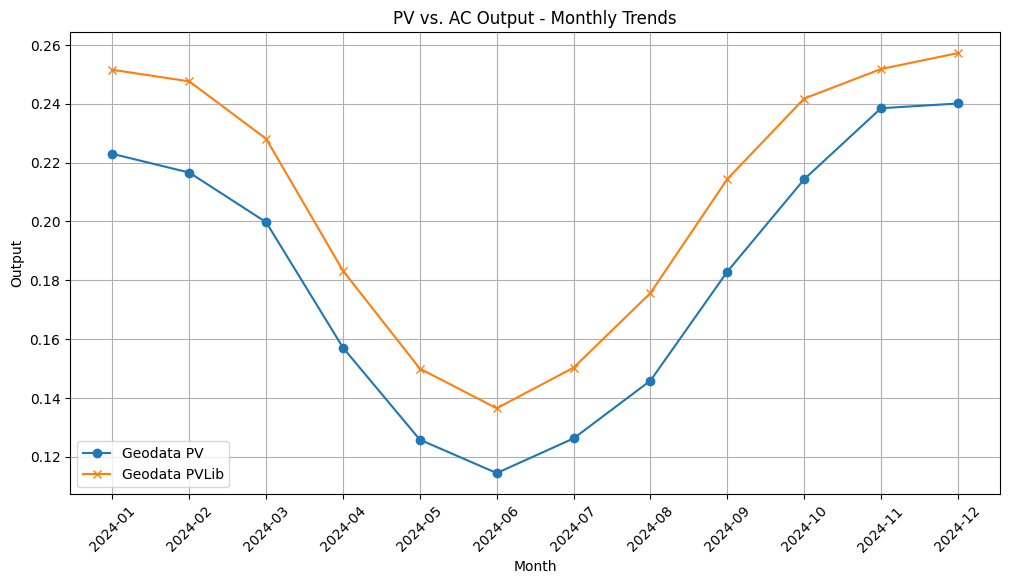

In [45]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_monthly.index.astype(str), df_monthly["pv"], label="Geodata PV", marker="o")
plt.plot(df_monthly.index.astype(str), df_monthly["ac_adj"], label="Geodata PVLib", marker="x")

# Formatting
plt.xlabel("Month")
plt.ylabel("Output")
plt.title("PV vs. AC Output - Monthly Trends")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Daily Heatmap - Calendar View

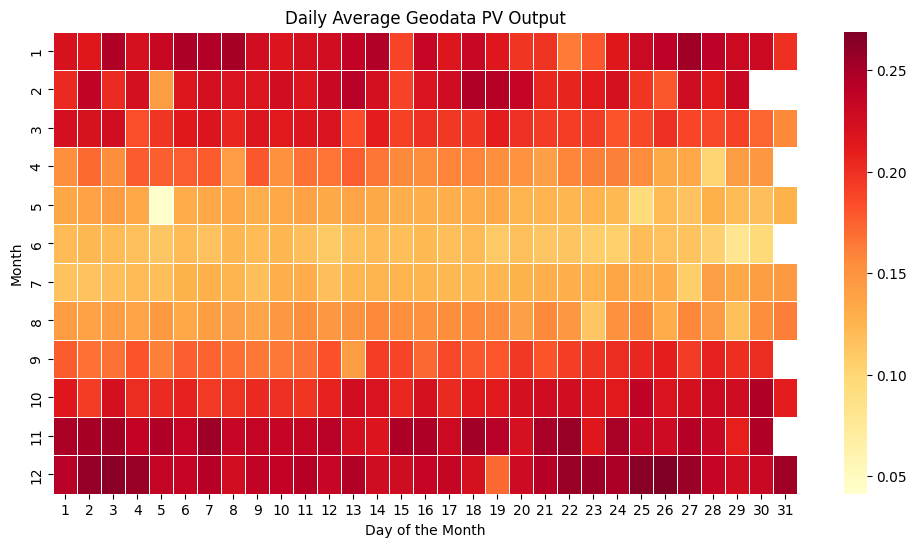

In [49]:
df_daily = df_merged.reset_index()
df_daily = df_daily.groupby(df_daily["time"].dt.date)[["pv", "ac_adj"]].mean().reset_index()
df_daily["time"] = pd.to_datetime(df_daily["time"])  

df_daily["day"] = df_daily["time"].dt.day
df_daily["month"] = df_daily["time"].dt.month

heatmap_data = df_daily.pivot(index="month", columns="day", values="pv")  
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.5, annot=False)
plt.xlabel("Day of the Month")
plt.ylabel("Month")
plt.title("Daily Average Geodata PV Output")
plt.show()

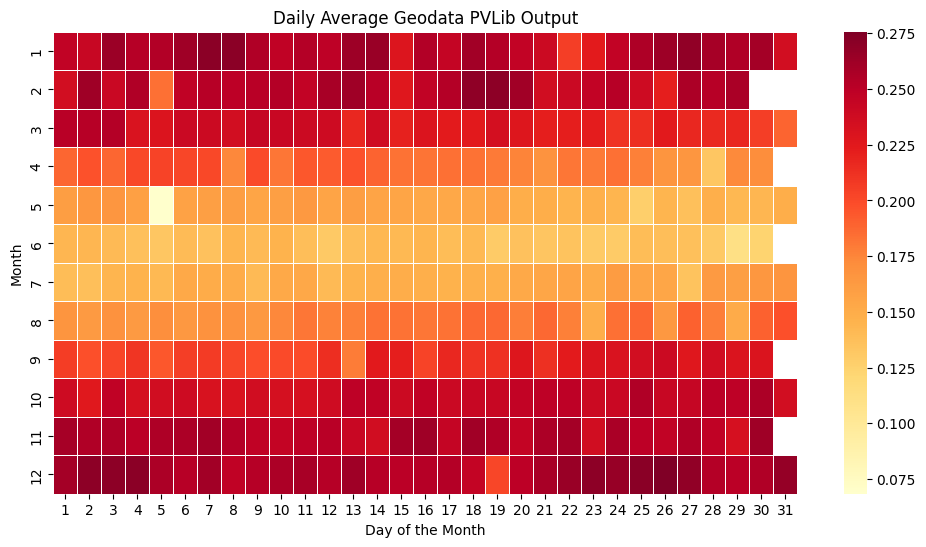

In [50]:
heatmap_data = df_daily.pivot(index="month", columns="day", values="ac_adj")  
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.5, annot=False)
plt.xlabel("Day of the Month")
plt.ylabel("Month")
plt.title("Daily Average Geodata PVLib Output")
plt.show()

### Boxplots

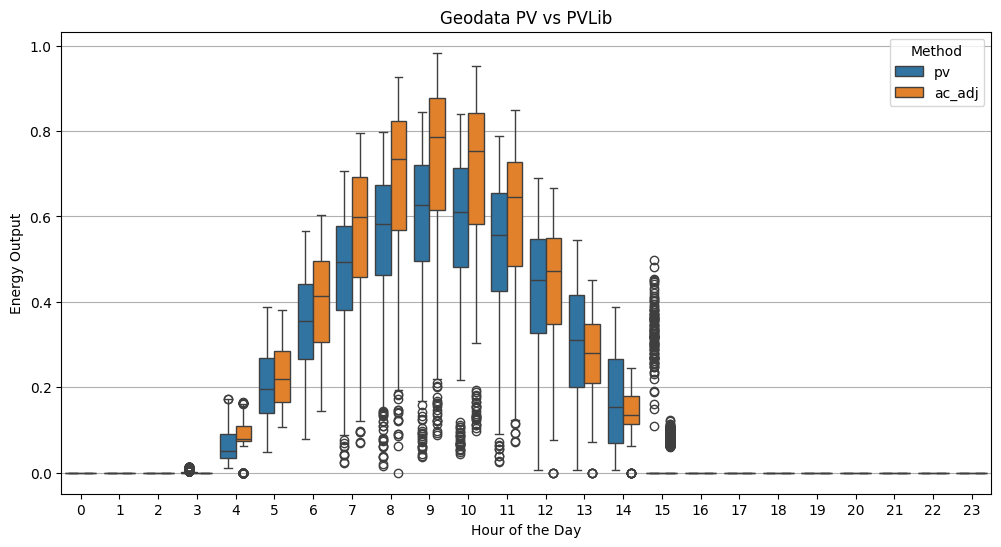

In [52]:
df_hourly = df_merged.reset_index()
df_hourly["hour"] = df_hourly["time"].dt.hour

# Melt the data for seaborn (long format for boxplots)
df_melted = df_hourly.melt(id_vars=["hour"], value_vars=["pv", "ac_adj"], var_name="Method", value_name="Output")

# Plot boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(x="hour", y="Output", hue="Method", data=df_melted)

# Formatting
plt.xlabel("Hour of the Day")
plt.ylabel("Energy Output")
plt.title("Geodata PV vs PVLib")
plt.legend(title="Method")
plt.grid(axis="y")
plt.show()